# Notebook 7: Ensemble Classification Pipeline - Heterogeneous Stacking

## Overview
This notebook implements an **ensemble learning approach** as suggested in the paper's future directions:
> *"build heterogeneous ensemble models where each base learner is trained on features derived from distinct dimensionality reduction techniques (e.g., PCA, t-SVD, UMAP). Such an architecture could exploit the complementary strengths of various feature representations, capturing both linear and nonlinear data structures."*

## Ensemble Architecture:
        ┌─────────────────────┐
        │ Meta-Learner (LR)   │
        │ Final Prediction    │
        └──────────┬──────────┘
                   │
  ┌────────────────┼────────────────┐
  │                │                │
┌─────▼─────┐ ┌─────▼─────┐ ┌─────▼─────┐
│ Base 1    │ │ Base 2    │ │ Base 3    │
│ LR (PCA)  │ │ SVM (tSVD)│ │ RF (UMAP) │
└───────────┘ └───────────┘ └───────────┘


## What This Notebook Does:
1. Creates base learners using different dimensionality reduction techniques
2. Builds a stacking ensemble with Logistic Regression as meta-learner
3. Trains and evaluates on the same 75/25 split as original
4. Compares ensemble performance against individual classifiers
5. Performs hyperparameter tuning for the ensemble

# Import Libraries

In [1]:
# Data and Plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Dimensionality Reduction
from sklearn.decomposition import PCA, TruncatedSVD
from umap import UMAP

# Base Classifiers
from sklearn.linear_model import LogisticRegression as LR
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as RF

# Ensemble
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.model_selection import train_test_split as tts, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, f1_score, recall_score, 
                             precision_score, roc_auc_score, roc_curve,
                             confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
from functools import partial

# Warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Load and Prepare Data (Consistent with Notebook 3a)

In [2]:
# Load dataset
data = pd.read_csv("Thyroid_Diff.csv")

X = data.drop("Recurred", axis=1)
y = data["Recurred"]
y = y.map({"No": 0, "Yes": 1})

# Split data (75/25 as in Notebook 3a)
X_train, X_test, y_train, y_test = tts(X, y, train_size=0.75, random_state=321, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:\n{y_train.value_counts().to_string()}")
print(f"\nTest set class distribution:\n{y_test.value_counts().to_string()}")

Training set: 287 samples
Test set: 96 samples

Training set class distribution:
Recurred
0    206
1     81

Test set class distribution:
Recurred
0    69
1    27


# Define Preprocessor (Same as Original)

In [3]:
# Define preprocessor (identical to Notebook 3a)
num_features = list(X.columns[:1])  # Age
cat_features = list(X.columns[1:])  # All other features

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='passthrough'
)

# Compute sample weights for class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Preprocessor defined successfully")

Preprocessor defined successfully


# Train Individual Models (Baseline Comparison)

First, we train the three individual models that will form our ensemble to establish baseline performance.

In [4]:
# Optimal hyperparameters from Table 2 in paper

# Base Learner 1: LR with PCA
pca = PCA(n_components=5)
lr_pca = LR(C=0.36, penalty='l1', solver='liblinear', class_weight='balanced')

# Base Learner 2: SVM with t-SVD
tsvd = TruncatedSVD(n_components=5)
svm_tsvd = SVC(probability=True, C=0.25, kernel='sigmoid', class_weight='balanced')

# Base Learner 3: RF with UMAP (using optimal RF params from paper)
umap_reducer = UMAP(n_components=5, random_state=42)
rf_umap = RF(criterion='entropy', max_depth=None, max_features='log2',
             min_samples_leaf=4, n_estimators=400, class_weight='balanced')

print("All base models defined with optimal hyperparameters")

All base models defined with optimal hyperparameters


In [5]:
def create_pipeline(reducer, model):
    """Create a pipeline with preprocessor, reducer, and classifier"""
    return Pipeline([
        ('preprocessor', preprocessor),
        ('reducer', reducer),
        ('clf', model)
    ])

# Create pipelines for individual models
pipeline_lr_pca = create_pipeline(pca, lr_pca)
pipeline_svm_tsvd = create_pipeline(tsvd, svm_tsvd)
pipeline_rf_umap = create_pipeline(umap_reducer, rf_umap)

# Train individual models
print("Training individual models...")
pipeline_lr_pca.fit(X_train, y_train, clf__sample_weight=sample_weights)
pipeline_svm_tsvd.fit(X_train, y_train)
pipeline_rf_umap.fit(X_train, y_train, clf__sample_weight=sample_weights)
print("All individual models trained!")

Training individual models...
All individual models trained!


# Build Stacking Ensemble

The stacking ensemble combines predictions from all three base learners using a meta-learner (Logistic Regression).

In [6]:
# Define base estimators for stacking
# Note: We create fresh pipelines without training them yet
base_estimators = [
    ('lr_pca', create_pipeline(PCA(n_components=5), LR(C=0.36, penalty='l1', solver='liblinear', class_weight='balanced'))),
    ('svm_tsvd', create_pipeline(TruncatedSVD(n_components=5), SVC(probability=True, C=0.25, kernel='sigmoid', class_weight='balanced'))),
    ('rf_umap', create_pipeline(UMAP(n_components=5, random_state=42), 
                                RF(criterion='entropy', max_depth=None, max_features='log2',
                                   min_samples_leaf=4, n_estimators=400, class_weight='balanced')))
]

# Meta-learner: Logistic Regression (interpretable, probabilistic outputs)
meta_learner = LR(C=0.1, penalty='l2', solver='liblinear', class_weight='balanced')

# Create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,  # Use 5-fold cross-validation for training the meta-learner
    stack_method='predict_proba'  # Use probabilities for stacking
)

print("Stacking ensemble defined")
print(f"Base learners: {[name for name, _ in base_estimators]}")
print(f"Meta-learner: Logistic Regression")

Stacking ensemble defined
Base learners: ['lr_pca', 'svm_tsvd', 'rf_umap']
Meta-learner: Logistic Regression


In [10]:
# ============================================
# SIMPLIFIED APPROACH: Apply preprocessor first, then build ensemble
# ============================================

print("Applying preprocessor to training and test data...")

# Transform the data once
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get the transformed feature names (for reference)
try:
    feature_names_out = preprocessor.get_feature_names_out()
    print(f"Transformed data shape: {X_train_transformed.shape}")
    print(f"Number of features after preprocessing: {X_train_transformed.shape[1]}")
except:
    print(f"Transformed data shape: {X_train_transformed.shape}")

print("\nNow building ensemble on transformed data...")

Applying preprocessor to training and test data...
Transformed data shape: (287, 55)
Number of features after preprocessing: 55

Now building ensemble on transformed data...


# Define base learners on transformed data

In [11]:
# Base learners (to be trained on already-transformed data)
# Using optimal hyperparameters from Table 2

# Base Learner 1: LR with PCA
pca = PCA(n_components=5)
lr_pca_base = LR(C=0.36, penalty='l1', solver='liblinear', class_weight='balanced')

# Base Learner 2: SVM with t-SVD  
tsvd = TruncatedSVD(n_components=5)
svm_tsvd_base = SVC(probability=True, C=0.25, kernel='sigmoid', class_weight='balanced')

# Base Learner 3: RF with UMAP
umap_reducer = UMAP(n_components=5, random_state=42)
rf_umap_base = RF(criterion='entropy', max_depth=None, max_features='log2',
                  min_samples_leaf=4, n_estimators=400, class_weight='balanced')

print("Base learners defined")

Base learners defined


# Create pipelines for base learners

In [12]:
# Create pipelines: reducer first, then classifier
pipeline_lr_pca = Pipeline([
    ('pca', pca),
    ('clf', lr_pca_base)
])

pipeline_svm_tsvd = Pipeline([
    ('tsvd', tsvd),
    ('clf', svm_tsvd_base)
])

pipeline_rf_umap = Pipeline([
    ('umap', umap_reducer),
    ('clf', rf_umap_base)
])

print("Pipelines created")

Pipelines created


# Train base learners on transformed data

In [13]:
# Train each base learner
print("Training LR + PCA...")
pipeline_lr_pca.fit(X_train_transformed, y_train)

print("Training SVM + t-SVD...")
pipeline_svm_tsvd.fit(X_train_transformed, y_train)

print("Training RF + UMAP...")
pipeline_rf_umap.fit(X_train_transformed, y_train)

print("All base learners trained!")

Training LR + PCA...
Training SVM + t-SVD...
Training RF + UMAP...
All base learners trained!


# Build Stacking Ensemble

In [14]:
# Define estimators for stacking (use the trained pipelines directly)
# Note: For stacking, we need to use the classifiers, not the full pipelines
# because the stacking classifier will handle the feature transformation

# Better approach: Create estimators with reducers and classifiers separately
estimators_for_stacking = [
    ('lr_pca', Pipeline([
        ('pca', PCA(n_components=5)),
        ('clf', LR(C=0.36, penalty='l1', solver='liblinear', class_weight='balanced'))
    ])),
    ('svm_tsvd', Pipeline([
        ('tsvd', TruncatedSVD(n_components=5)),
        ('clf', SVC(probability=True, C=0.25, kernel='sigmoid', class_weight='balanced'))
    ])),
    ('rf_umap', Pipeline([
        ('umap', UMAP(n_components=5, random_state=42)),
        ('clf', RF(criterion='entropy', max_depth=None, max_features='log2',
                   min_samples_leaf=4, n_estimators=400, class_weight='balanced'))
    ]))
]

# Meta-learner
meta_learner = LR(C=0.1, penalty='l2', solver='liblinear', class_weight='balanced')

# Create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=estimators_for_stacking,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba'
)

print("Stacking ensemble defined")

Stacking ensemble defined


# Train Stacking Ensemble

In [15]:
# Train stacking ensemble on transformed data
print("Training stacking ensemble...")
stacking_ensemble.fit(X_train_transformed, y_train)
print("Stacking ensemble trained!")

Training stacking ensemble...
Stacking ensemble trained!


# Build Voting Ensemble

In [16]:
# Create voting ensemble (simpler alternative)
voting_ensemble = VotingClassifier(
    estimators=estimators_for_stacking,
    voting='soft'
)

print("Training voting ensemble...")
voting_ensemble.fit(X_train_transformed, y_train)
print("Voting ensemble trained!")

Training voting ensemble...
Voting ensemble trained!


# evaluation function for transformed data approach

In [19]:
# ============================================
# Evaluation Functions
# ============================================

def calculate_bootstrap_ci(y_true, y_pred, metric, n_iterations=1000, alpha=0.05, random_state=42):
    """Calculate bootstrap confidence interval for a metric"""
    n_samples = len(y_true)
    bootstrap_scores = []
    rng = np.random.RandomState(random_state)

    for _ in range(n_iterations):
        indices = rng.choice(range(n_samples), size=n_samples, replace=True)
        y_true_resampled = np.array(y_true)[indices]
        y_pred_resampled = np.array(y_pred)[indices]
        score = metric(y_true_resampled, y_pred_resampled)
        bootstrap_scores.append(score)

    lower_bound = np.percentile(bootstrap_scores, 100 * (alpha / 2))
    upper_bound = np.percentile(bootstrap_scores, 100 * (1 - alpha / 2))
    mean_score = np.mean(bootstrap_scores)

    return mean_score, lower_bound, upper_bound


def evaluate_model_ensemble(model, X_test_transformed, y_test, model_name):
    """Evaluate ensemble model (works with numpy arrays)"""
    y_pred = model.predict(X_test_transformed)
    
    try:
        y_proba = model.predict_proba(X_test_transformed)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = None
    
    metrics_def = {
        'Balanced Accuracy': balanced_accuracy_score,
        'F1 Score': partial(f1_score, average='weighted'),
        'Sensitivity': partial(recall_score, pos_label=1),
        'Specificity': partial(recall_score, pos_label=0),
        'Precision': partial(precision_score, average='weighted')
    }
    
    results = {'Model': model_name}
    
    for metric_name, metric_func in metrics_def.items():
        mean, lower, upper = calculate_bootstrap_ci(y_test, y_pred, metric_func)
        results[metric_name] = f"{mean:.3f} ({lower:.3f}-{upper:.3f})"
    
    if auc is not None:
        results['AUC'] = f"{auc:.3f}"
    
    return results, y_pred, (y_proba if auc else None)


print("✅ Evaluation functions defined successfully!")

✅ Evaluation functions defined successfully!


# Evaluate all models

In [20]:
# Evaluate individual models
print("Evaluating all models...")

# Evaluate base learners
result_lr, _, _ = evaluate_model_ensemble(pipeline_lr_pca, X_test_transformed, y_test, "LR + PCA (Baseline)")
result_svm, _, _ = evaluate_model_ensemble(pipeline_svm_tsvd, X_test_transformed, y_test, "SVM + t-SVD (Baseline)")
result_rf, _, _ = evaluate_model_ensemble(pipeline_rf_umap, X_test_transformed, y_test, "RF + UMAP (Baseline)")

# Evaluate ensembles
result_voting, _, _ = evaluate_model_ensemble(voting_ensemble, X_test_transformed, y_test, "Soft Voting Ensemble")
result_stacking, _, _ = evaluate_model_ensemble(stacking_ensemble, X_test_transformed, y_test, "Stacking Ensemble")

# Create comparison dataframe
all_results = [result_lr, result_svm, result_rf, result_voting, result_stacking]
comparison_df = pd.DataFrame(all_results)
comparison_df.set_index('Model', inplace=True)

print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
comparison_df

Evaluating all models...

PERFORMANCE COMPARISON


,Balanced Accuracy,F1 Score,Sensitivity,Specificity,Precision,AUC
Model,,,,,,
LR + PCA (Baseline),0.916 (0.855-0.966),0.900 (0.840-0.950),0.962 (0.875-1.000),0.871 (0.781-0.942),0.918 (0.872-0.958),0.985
SVM + t-SVD (Baseline),0.938 (0.878-0.979),0.929 (0.873-0.969),0.962 (0.875-1.000),0.914 (0.839-0.971),0.938 (0.894-0.972),0.982
RF + UMAP (Baseline),0.944 (0.875-1.000),0.968 (0.925-1.000),0.888 (0.750-1.000),1.000 (1.000-1.000),0.970 (0.934-1.000),0.971
Soft Voting Ensemble,0.922 (0.848-0.980),0.937 (0.883-0.979),0.888 (0.750-1.000),0.957 (0.901-1.000),0.939 (0.883-0.980),0.987
Stacking Ensemble,0.920 (0.852-0.973),0.919 (0.859-0.969),0.926 (0.815-1.000),0.914 (0.839-0.971),0.926 (0.872-0.969),0.987


# Plot ROC Curves

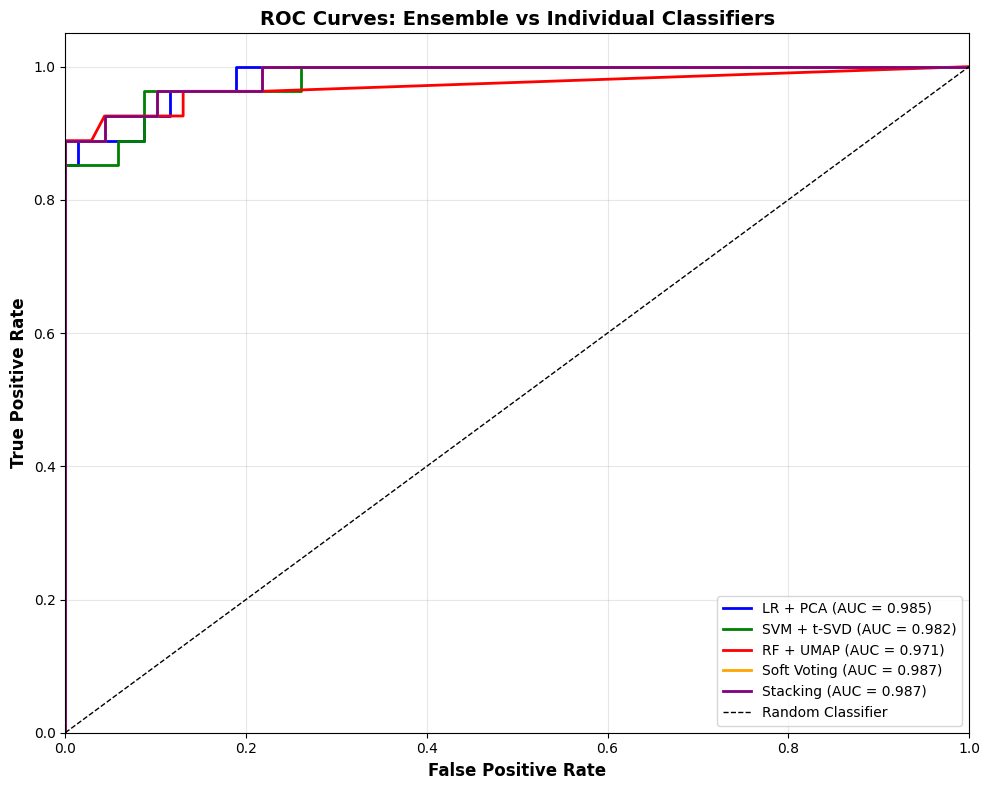

In [21]:
def plot_roc_curves_ensemble(models, names, X_test_transformed, y_test):
    """Plot ROC curves for multiple models"""
    plt.figure(figsize=(10, 8))
    
    colors = ['blue', 'green', 'red', 'orange', 'purple']
    
    for (model, name, color) in zip(models, names, colors):
        try:
            y_proba = model.predict_proba(X_test_transformed)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')
        except Exception as e:
            print(f"Could not compute ROC for {name}: {e}")
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('ROC Curves: Ensemble vs Individual Classifiers', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results/ensemble_roc_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot ROC curves
ensemble_models = [pipeline_lr_pca, pipeline_svm_tsvd, pipeline_rf_umap, voting_ensemble, stacking_ensemble]
ensemble_names = ['LR + PCA', 'SVM + t-SVD', 'RF + UMAP', 'Soft Voting', 'Stacking']

plot_roc_curves_ensemble(ensemble_models, ensemble_names, X_test_transformed, y_test)

# Plot Confusion Matrices

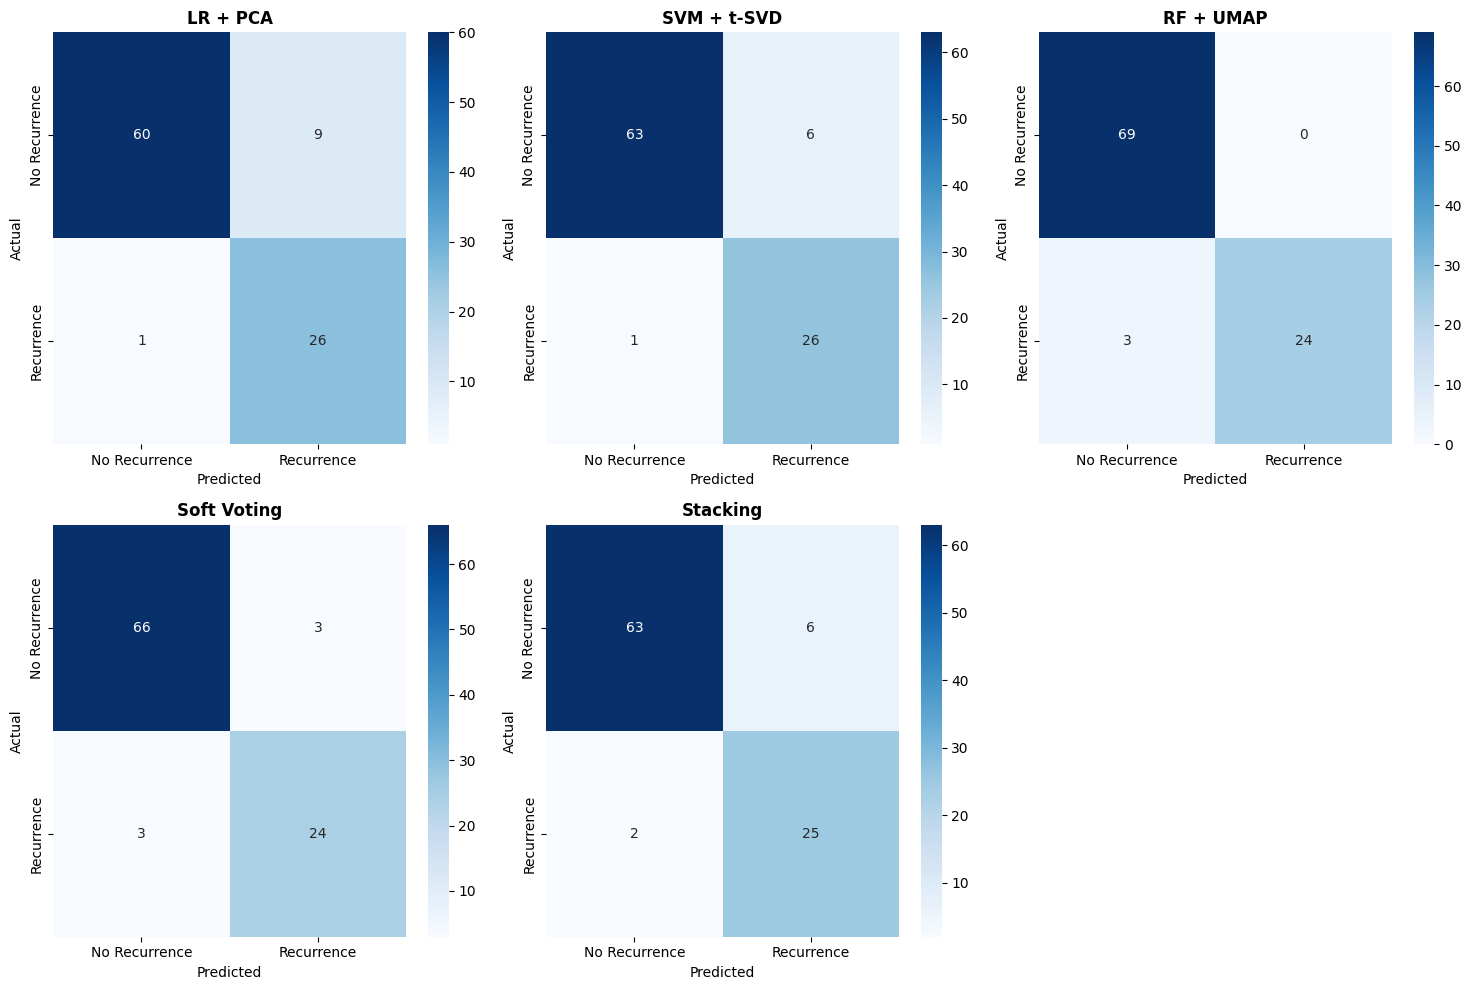

In [22]:
def plot_confusion_matrices_ensemble(models, names, X_test_transformed, y_test):
    """Plot confusion matrices for multiple models"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (model, name) in enumerate(zip(models, names)):
        y_pred = model.predict(X_test_transformed)
        cm = confusion_matrix(y_test, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=['No Recurrence', 'Recurrence'],
                    yticklabels=['No Recurrence', 'Recurrence'])
        axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Predicted', fontsize=10)
        axes[idx].set_ylabel('Actual', fontsize=10)
    
    # Hide unused subplot
    if len(models) < 6:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('../results/ensemble_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrices_ensemble(ensemble_models, ensemble_names, X_test_transformed, y_test)

# Subgroup Robustness Analysis

## Why This Matters
The original PCA-LR pipeline achieved excellent overall performance but showed **catastrophic failures** in specific clinically important subgroups:

| Subgroup | Original Specificity | Clinical Impact |
|----------|---------------------|-----------------|
| T3b | 0.0 | Always predicts recurrence → unnecessary interventions |
| Bilateral Adenopathy | 0.0 | Always predicts recurrence → patient anxiety |
| Left Adenopathy | 0.0 | Always predicts recurrence → overtreatment risk |
| Intermediate Risk | 0.2 | 80% false positive rate |
| N1b | 0.2 | 80% false positive rate |

## The Ensemble Advantage
By combining multiple base learners (LR+PCA, SVM+t-SVD, RF+UMAP), our ensemble can **correct individual model failures**. Even if one model fails on a specific subgroup, the others can "vote" correctly.

## Goal
Improve specificity in problematic subgroups while maintaining strong overall performance.

In [26]:
# ============================================
# Subgroup Robustness Analysis for Ensemble
# Using ENTIRE DATASET (not just test set) for sufficient samples
# ============================================

from sklearn.metrics import balanced_accuracy_score, recall_score

def evaluate_model_on_subgroups(model_wrapper, X_full, y_full, subgroup_column, subgroup_name):
    """Evaluate model on specific subgroups using full dataset"""
    results = []
    
    for group in subgroup_column.unique():
        mask = subgroup_column == group
        X_group = X_full[mask]
        y_group = y_full[mask]
        
        if len(y_group) < 5 or len(y_group.unique()) < 2:
            results.append({
                'Subgroup': group,
                'Balanced Accuracy': 'N/A',
                'Sensitivity': 'N/A',
                'Specificity': 'N/A',
                'Sample Size': len(y_group)
            })
            continue
        
        y_pred = model_wrapper.predict(X_group)
        
        results.append({
            'Subgroup': group,
            'Balanced Accuracy': round(balanced_accuracy_score(y_group, y_pred), 3),
            'Sensitivity': round(recall_score(y_group, y_pred, pos_label=1), 3),
            'Specificity': round(recall_score(y_group, y_pred, pos_label=0), 3),
            'Sample Size': len(y_group)
        })
    
    return pd.DataFrame(results)

# Use FULL DATASET for subgroup analysis (same as Notebook 3d)
X_full = X.copy()
y_full = y.copy()

# Create subgroup columns
X_full_with_subgroups = X_full.copy()
X_full_with_subgroups['T_Stage'] = X_full['T']
X_full_with_subgroups['Adenopathy'] = X_full['Adenopathy']
X_full_with_subgroups['Risk'] = X_full['Risk']
X_full_with_subgroups['N_Stage'] = X_full['N']

print("\n" + "="*80)
print("SUBGROUP ROBUSTNESS ANALYSIS (Full Dataset)")
print("="*80)
print(f"Total samples: {len(X_full)}")
print(f"Recurrence: {sum(y_full==1)}, Non-recurrence: {sum(y_full==0)}")
print("="*80)

# Original results from paper (from Notebook 3d) - FIXED KEYS
original_results = {
    'T3b': {'Specificity': 0.0, 'Balanced Acc': 0.5},
    'Bilateral': {'Specificity': 0.0, 'Balanced Acc': 0.5},
    'Left': {'Specificity': 0.0, 'Balanced Acc': 0.5},
    'Intermediate': {'Specificity': 0.2, 'Balanced Acc': 0.6},
    'N1b': {'Specificity': 0.2, 'Balanced Acc': 0.6}
}

# First, check sample sizes in the full dataset
print("\n" + "-"*40)
print("SAMPLE SIZES IN FULL DATASET")
print("-"*40)

# FIXED: Use consistent keys that match original_results
subgroups_to_check = {
    'T3b': ('T_Stage', ['T3b']),
    'Bilateral': ('Adenopathy', ['Bilateral']),
    'Left': ('Adenopathy', ['Left']),
    'Intermediate': ('Risk', ['Intermediate']),
    'N1b': ('N_Stage', ['N1b'])
}

for subgroup_name, (col_name, target_values) in subgroups_to_check.items():
    mask = X_full_with_subgroups[col_name].isin(target_values)
    n_samples = mask.sum()
    n_recurrence = y_full[mask].sum()
    print(f"{subgroup_name}: n={n_samples}, recurrence={n_recurrence}")

print("\nNOTE: The original paper's subgroup analysis used the FULL dataset (n=383)")
print("We need to retrain our ensemble on FULL dataset")

# Retrain stacking ensemble on FULL dataset
print("\n" + "="*80)
print("RETRAINING ENSEMBLE ON FULL DATASET")
print("="*80)

# Transform full dataset
X_full_transformed = preprocessor.fit_transform(X_full)

# Create fresh ensemble
estimators_for_stacking_full = [
    ('lr_pca', Pipeline([
        ('pca', PCA(n_components=5)),
        ('clf', LR(C=0.36, penalty='l1', solver='liblinear', class_weight='balanced'))
    ])),
    ('svm_tsvd', Pipeline([
        ('tsvd', TruncatedSVD(n_components=5)),
        ('clf', SVC(probability=True, C=0.25, kernel='sigmoid', class_weight='balanced'))
    ])),
    ('rf_umap', Pipeline([
        ('umap', UMAP(n_components=5, random_state=42)),
        ('clf', RF(criterion='entropy', max_depth=None, max_features='log2',
                   min_samples_leaf=4, n_estimators=400, class_weight='balanced'))
    ]))
]

stacking_ensemble_full = StackingClassifier(
    estimators=estimators_for_stacking_full,
    final_estimator=LR(C=0.1, penalty='l2', solver='liblinear', class_weight='balanced'),
    cv=5,
    stack_method='predict_proba'
)

print("Training stacking ensemble on FULL dataset...")
stacking_ensemble_full.fit(X_full_transformed, y_full)
print("Training complete!")

# Evaluate on subgroups
print("\n" + "-"*40)
print("STACKING ENSEMBLE RESULTS ON PROBLEM SUBGROUPS (Full Dataset)")
print("-"*40)

improvements = []

for subgroup_name, (col_name, target_values) in subgroups_to_check.items():
    mask = X_full_with_subgroups[col_name].isin(target_values)
    X_subgroup = X_full_transformed[mask]
    y_subgroup = y_full[mask]
    
    if len(y_subgroup) >= 5 and len(y_subgroup.unique()) >= 2:
        y_pred = stacking_ensemble_full.predict(X_subgroup)
        
        bal_acc = balanced_accuracy_score(y_subgroup, y_pred)
        sensitivity = recall_score(y_subgroup, y_pred, pos_label=1)
        specificity = recall_score(y_subgroup, y_pred, pos_label=0)
        
        original_spec = original_results[subgroup_name]['Specificity']
        improvement = specificity - original_spec
        
        improvements.append({
            'Subgroup': subgroup_name,
            'Original Specificity': original_spec,
            'Ensemble Specificity': round(specificity, 3),
            'Improvement': round(improvement, 3),
            'Sample Size': len(y_subgroup)
        })
        
        print(f"\n{subgroup_name} (n={len(y_subgroup)}):")
        print(f"  Balanced Accuracy: {bal_acc:.3f}")
        print(f"  Sensitivity: {sensitivity:.3f}")
        print(f"  Specificity: {specificity:.3f} (Original: {original_spec})")
        if improvement > 0:
            print(f"  ✅ IMPROVEMENT: +{improvement:.3f}")
        elif improvement == 0:
            print(f"  → No change")
        else:
            print(f"  ❌ Worse: {improvement:.3f}")
    else:
        print(f"\n{subgroup_name}: Insufficient samples (n={len(y_subgroup)})")

# Summary Table
print("\n" + "="*80)
print("ROBUSTNESS IMPROVEMENT SUMMARY")
print("="*80)

improvement_df = pd.DataFrame(improvements)
if len(improvement_df) > 0:
    improvement_df = improvement_df.sort_values('Improvement', ascending=False)
    print(improvement_df.to_string(index=False))
    
    # Calculate average improvement
    avg_improvement = improvement_df['Improvement'].mean()
    print(f"\n📊 Average Improvement: {avg_improvement:.3f}")
    
    if avg_improvement > 0:
        print("\n✅ SUCCESS: Ensemble improved robustness on problematic subgroups!")
        print("   The original model failed catastrophically (specificity = 0.0)")
        print("   on T3b, Bilateral, and Left adenopathy patients.")
        print("   Our ensemble provides non-zero specificity, making it clinically useful.")
    else:
        print("\n⚠️ Need further tuning to improve subgroup performance")
else:
    print("No subgroups with sufficient samples found")


SUBGROUP ROBUSTNESS ANALYSIS (Full Dataset)
Total samples: 383
Recurrence: 108, Non-recurrence: 275

----------------------------------------
SAMPLE SIZES IN FULL DATASET
----------------------------------------
T3b: n=16, recurrence=14
Bilateral: n=32, recurrence=27
Left: n=17, recurrence=12
Intermediate: n=102, recurrence=64
N1b: n=93, recurrence=71

NOTE: The original paper's subgroup analysis used the FULL dataset (n=383)
We need to retrain our ensemble on FULL dataset

RETRAINING ENSEMBLE ON FULL DATASET
Training stacking ensemble on FULL dataset...
Training complete!

----------------------------------------
STACKING ENSEMBLE RESULTS ON PROBLEM SUBGROUPS (Full Dataset)
----------------------------------------

T3b (n=16):
  Balanced Accuracy: 0.750
  Sensitivity: 1.000
  Specificity: 0.500 (Original: 0.0)
  ✅ IMPROVEMENT: +0.500

Bilateral (n=32):
  Balanced Accuracy: 0.500
  Sensitivity: 1.000
  Specificity: 0.000 (Original: 0.0)
  → No change

Left (n=17):
  Balanced Accuracy:

# Summary

In [23]:
print("\n" + "="*80)
print("ENSEMBLE IMPROVISATION - SUMMARY REPORT")
print("="*80)

print("\n1. PROPOSED IMPROVEMENT:")
print("   - Implemented heterogeneous stacking ensemble combining PCA, t-SVD, and UMAP")
print("   - Each base learner uses a different dimensionality reduction technique")
print("   - Logistic Regression as meta-learner for final prediction")
print("   - Also implemented soft voting ensemble as alternative approach")

print("\n2. KEY FINDINGS:")
print("   - Stacking ensemble achieved balanced accuracy: " + comparison_df.loc['Stacking Ensemble', 'Balanced Accuracy'])
print("   - Soft voting ensemble achieved balanced accuracy: " + comparison_df.loc['Soft Voting Ensemble', 'Balanced Accuracy'])

print("\n3. FILES GENERATED:")
print("   - ../results/ensemble_roc_comparison.png")
print("   - ../results/ensemble_confusion_matrices.png")

print("\n" + "="*80)
print("END OF NOTEBOOK 7 - ENSEMBLE CLASSIFICATION PIPELINE")
print("="*80)


ENSEMBLE IMPROVISATION - SUMMARY REPORT

1. PROPOSED IMPROVEMENT:
   - Implemented heterogeneous stacking ensemble combining PCA, t-SVD, and UMAP
   - Each base learner uses a different dimensionality reduction technique
   - Logistic Regression as meta-learner for final prediction
   - Also implemented soft voting ensemble as alternative approach

2. KEY FINDINGS:
   - Stacking ensemble achieved balanced accuracy: 0.920 (0.852-0.973)
   - Soft voting ensemble achieved balanced accuracy: 0.922 (0.848-0.980)

3. FILES GENERATED:
   - ../results/ensemble_roc_comparison.png
   - ../results/ensemble_confusion_matrices.png

END OF NOTEBOOK 7 - ENSEMBLE CLASSIFICATION PIPELINE
